In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from IPython.display import Image

# Reproducible anti-correlated AR(1) process parameters.
SEED = 8
PHI = -0.8
N_STEPS = 20
SIGMA = 0.8

# Animation controls.
START_FRAME = 1
FRAME_STRIDE = 1
INTERVAL_MS = 140
FPS = 8
FADE_FRAMES = 8
HOLD_FRAMES = 4
OUTPUT_GIF = "joint_pdf_animation.gif"

rng = np.random.default_rng(SEED)
eps = rng.normal(loc=0.0, scale=SIGMA, size=N_STEPS)
y = np.zeros(N_STEPS)
for t in range(1, N_STEPS):
    y[t] = PHI * y[t - 1] + eps[t]

# Lag-1 pairs for the joint PDF p(y_t, y_{t-1}).
x_next = y[1:]   # y_t, right-panel x-axis
y_prev = y[:-1]  # y_{t-1}, right-panel y-axis

# Precompute a smooth KDE surface for consistent right-panel visuals.
xy = np.vstack([x_next, y_prev])
kde = gaussian_kde(xy)
margin = 0.35
xmin, xmax = x_next.min() - margin, x_next.max() + margin
ymin, ymax = y_prev.min() - margin, y_prev.max() + margin
grid_n = 120
xx, yy = np.meshgrid(np.linspace(xmin, xmax, grid_n), np.linspace(ymin, ymax, grid_n))
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# Shared y-range so connector lines can be horizontal across panels.
y_pad = 0.15 * (y.max() - y.min())
y_common_min = min(y.min(), y_prev.min()) - y_pad
y_common_max = max(y.max(), y_prev.max()) + y_pad

time = np.arange(N_STEPS)
# Transition base indices: frame t uses current y_t and conditional sample y_{t+1}.
base_indices = np.arange(START_FRAME, N_STEPS - 1, FRAME_STRIDE)

# Build staged animation states per t:
# 1) fade-in cross-panel thin connector,
# 2) fade-in thick horizontal slice on KDE,
# 3) show conditional density and fade-in sampled x marker,
# 4) hold before advancing to next t.
animation_states = []
for t_idx in base_indices:
    for k in range(FADE_FRAMES):
        alpha = (k + 1) / FADE_FRAMES
        animation_states.append((t_idx, "connector", alpha))
    for k in range(FADE_FRAMES):
        alpha = (k + 1) / FADE_FRAMES
        animation_states.append((t_idx, "slice", alpha))
    for k in range(FADE_FRAMES):
        alpha = (k + 1) / FADE_FRAMES
        animation_states.append((t_idx, "conditional", alpha))
    for _ in range(HOLD_FRAMES):
        animation_states.append((t_idx, "hold", 1.0))

print(
    f"Generated AR(1) process with phi={PHI}, {N_STEPS} points, "
    f"{len(base_indices)} transition points, and {len(animation_states)} animation states."
)

Generated AR(1) process with phi=-0.8, 20 points, 18 transition points, and 504 animation states.


In [14]:
fig = plt.figure(figsize=(12, 6.2), constrained_layout=True)
gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[3, 1],
    height_ratios=[3, 1],
)
# Keep time series and joint KDE on the same row so their y-axes are physically aligned.
ax_ts = fig.add_subplot(gs[0, 0])
ax_joint = fig.add_subplot(gs[0, 1])
ax_cond = fig.add_subplot(gs[1, 1], sharex=ax_joint)
ax_blank = fig.add_subplot(gs[1, 0])
ax_blank.axis("off")

# Left panel: observed trajectory over time.
line_ts, = ax_ts.plot([], [], lw=1.6, color="tab:blue")
point_ts, = ax_ts.plot([], [], marker="o", ms=5, color="tab:red")
ax_ts.set_xlim(0, N_STEPS - 1)
ax_ts.set_ylim(y_common_min, y_common_max)
ax_ts.set_title("Anti-correlated AR(1) time series")
ax_ts.set_xlabel("time t")
ax_ts.set_ylabel(r"current value $y_t$")
ax_ts.grid(alpha=0.25)

# Top-right panel: lag-1 joint PDF via KDE.
levels = np.linspace(zz.min(), zz.max(), 9)
ax_joint.contourf(xx, yy, zz, levels=levels, cmap="viridis", alpha=0.9)
ax_joint.contour(xx, yy, zz, levels=levels[::2], colors="white", linewidths=0.4, alpha=0.6)
ax_joint.set_xlim(xmin, xmax)
ax_joint.set_ylim(y_common_min, y_common_max)
ax_joint.set_title(r"Joint PDF $\mathbb{P}(y_{t+1}, y_t)$")
ax_joint.set_xlabel(r"x: next value $y_{t+1}$")
ax_joint.set_ylabel(r"y: current value $y_t$")
ax_joint.grid(alpha=0.2)

# Bottom-right panel: conditional 1D density p(y_{t+1} | y_t = current).
ax_cond.set_title(r"$\mathbb{P}(y_{t+1} | y_t)$")
ax_cond.set_xlabel(r"$y_{t+1}$")
ax_cond.set_ylabel("density")
ax_cond.grid(alpha=0.2)

# Dynamic artists.
current_pair, = ax_joint.plot([], [], marker="o", ms=6, color="tab:red")
slice_line, = ax_joint.plot([], [], color="tab:red", lw=2.6, alpha=0.0)
cond_curve, = ax_cond.plot([], [], color="tab:blue", lw=2.0, alpha=0.0)
cond_sample_line, = ax_cond.plot([], [], color="tab:red", lw=3.0, alpha=0.0)

# Connector drawn in figure coordinates so it can cross axes boundaries.
connector = Line2D([], [], transform=fig.transFigure, color="tab:gray", lw=0.8, alpha=0.0)
fig.add_artist(connector)

x_cond_grid = np.linspace(xmin, xmax, 240)


def _to_fig_coords(ax, x_data, y_data):
    """Map an (x,y) point in data coordinates to figure coordinates."""
    return fig.transFigure.inverted().transform(ax.transData.transform((x_data, y_data)))


def _conditional_density(y_curr):
    # p(x|y_curr) is proportional to p(x, y_curr). Normalize numerically.
    eval_points = np.vstack([x_cond_grid, np.full_like(x_cond_grid, y_curr)])
    joint_vals = kde(eval_points)
    area = np.trapz(joint_vals, x_cond_grid)
    if area <= 1e-12:
        return np.zeros_like(x_cond_grid)
    return joint_vals / area


def init():
    line_ts.set_data([], [])
    point_ts.set_data([], [])
    current_pair.set_data([], [])
    slice_line.set_data([], [])
    slice_line.set_alpha(0.0)
    cond_curve.set_data([], [])
    cond_curve.set_alpha(0.0)
    cond_sample_line.set_data([], [])
    cond_sample_line.set_alpha(0.0)
    connector.set_data([], [])
    connector.set_alpha(0.0)
    ax_cond.set_ylim(0.0, 1.0)
    return line_ts, point_ts, current_pair, slice_line, cond_curve, cond_sample_line, connector


def update(frame_state):
    t_idx, phase, alpha = frame_state
    y_curr = y[t_idx]
    y_next = y[t_idx + 1]

    line_ts.set_data(time[: t_idx + 1], y[: t_idx + 1])
    point_ts.set_data([t_idx], [y_curr])

    # Thin connector from current TS point to left edge of KDE panel.
    left_fig_xy = _to_fig_coords(ax_ts, t_idx, y_curr)
    right_fig_xy = _to_fig_coords(ax_joint, xmin, y_curr)
    connector.set_data([left_fig_xy[0], right_fig_xy[0]], [left_fig_xy[1], right_fig_xy[1]])

    # Thick horizontal slice on KDE at current y_t.
    slice_line.set_data([xmin, xmax], [y_curr, y_curr])

    cond_vals = _conditional_density(y_curr)
    cond_max = max(float(cond_vals.max()), 1e-6)
    ax_cond.set_ylim(0.0, cond_max * 1.15)
    cond_curve.set_data(x_cond_grid, cond_vals)

    # Sample marker in conditional plot: x equals the red point x on KDE.
    sample_height = np.interp(y_next, x_cond_grid, cond_vals)
    cond_sample_line.set_data([y_next, y_next], [0.0, sample_height])

    if phase == "connector":
        connector.set_alpha(alpha)
        slice_line.set_alpha(0.0)
        current_pair.set_data([], [])
        cond_curve.set_alpha(0.0)
        cond_sample_line.set_alpha(0.0)
    elif phase == "slice":
        connector.set_alpha(1.0)
        slice_line.set_alpha(alpha)
        current_pair.set_data([], [])
        cond_curve.set_alpha(0.0)
        cond_sample_line.set_alpha(0.0)
    elif phase == "conditional":
        connector.set_alpha(1.0)
        slice_line.set_alpha(1.0)
        current_pair.set_data([y_next], [y_curr])
        cond_curve.set_alpha(1.0)
        cond_sample_line.set_alpha(alpha)
    else:  # hold
        connector.set_alpha(1.0)
        slice_line.set_alpha(1.0)
        current_pair.set_data([y_next], [y_curr])
        cond_curve.set_alpha(1.0)
        cond_sample_line.set_alpha(1.0)

    return line_ts, point_ts, current_pair, slice_line, cond_curve, cond_sample_line, connector


anim = FuncAnimation(
    fig,
    update,
    frames=animation_states,
    init_func=init,
    interval=INTERVAL_MS,
    blit=False,
    repeat=True,
)

plt.close(fig)
anim

/var/folders/06/88893yxd5qg_yw5z0dncmm4r0000gp/T/ipykernel_41709/2932543447.py:64: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(joint_vals, x_cond_grid)


Saved animation to joint_pdf_animation.gif


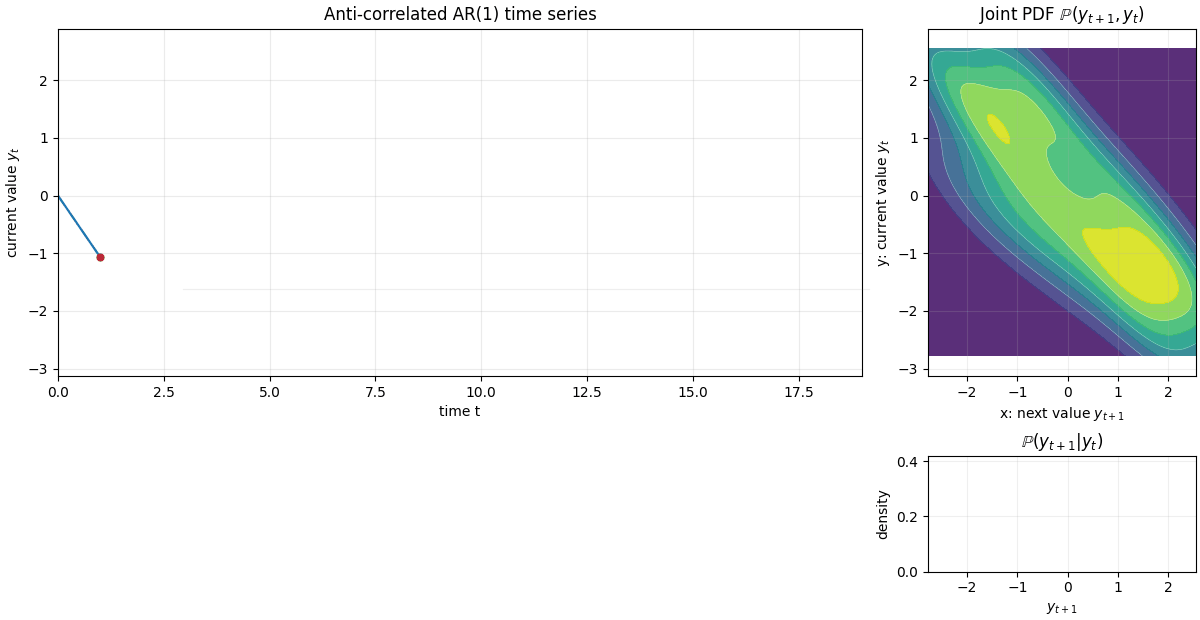

In [15]:
writer = PillowWriter(fps=FPS)
anim.save(OUTPUT_GIF, writer=writer)

print(f"Saved animation to {OUTPUT_GIF}")
Image(filename=OUTPUT_GIF)